<a href="https://colab.research.google.com/github/fox-n/ML_course_homeworks/blob/main/Copy_of_HW_2_1_%D0%9B%D1%96%D0%BD%D1%96%D0%B9%D0%BD%D0%B0_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%8F_%D0%B2%D1%96%D0%B4_%D0%B1%D0%B0%D0%B3%D0%B0%D1%82%D1%8C%D0%BE%D1%85_%D0%B7%D0%BC%D1%96%D0%BD%D0%BD%D0%B8%D1%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [336]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

!pip install scikit-learn --quiet
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

!pip -q install gdown
import gdown

In [337]:
url_application_data_csv_zip = "https://drive.google.com/file/d/148Mkilf0fRLJgquZs_Hq30-jrKsGLzVW/view?usp=sharing"
gdown.download(url_application_data_csv_zip, "cars.csv", fuzzy=True)


Downloading...
From: https://drive.google.com/uc?id=148Mkilf0fRLJgquZs_Hq30-jrKsGLzVW
To: /content/cars.csv
100%|██████████| 7.26k/7.26k [00:00<00:00, 14.7MB/s]


'cars.csv'

# Знайомство з даними

#Завдання 1.
** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [338]:
cars_df = pd.read_csv("cars.csv")
cars_df.head(5)

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


#Завдання 2.
** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [339]:
# приклад як викликати документацію, якщо у Вас pandas імпортований як pd
?pd.DataFrame.info

In [340]:
cars_df.shape

(100, 13)

In [341]:
#кількість категоріальних колонок
len(cars_df.select_dtypes(include = "object").columns)

5

In [342]:
#кількість числових колонок
len(cars_df.select_dtypes(include="number").columns)

8

In [343]:
cars_df.select_dtypes('object')

,Brand,Model,Fuel_Type,Transmission,Owner_Type
0,Toyota,Corolla,Petrol,Manual,First
1,Honda,Civic,Petrol,Automatic,Second
2,Ford,Mustang,Petrol,Automatic,First
3,Maruti,Swift,Diesel,Manual,Third
4,Hyundai,Sonata,Diesel,Automatic,Second
...,...,...,...,...,...
95,Mercedes,C-Class,Diesel,Automatic,First
96,Toyota,Innova Crysta,Diesel,Manual,Second
97,Ford,EcoSport,Petrol,Manual,Third
98,Hyundai,Verna,Petrol,Automatic,Second


In [344]:
#унікальні значення в колонці Brand
cars_df['Brand'].unique()

array(['Toyota', 'Honda', 'Ford', 'Maruti', 'Hyundai', 'Tata', 'Mahindra',
       'Volkswagen', 'Audi', 'BMW', 'Mercedes'], dtype=object)

In [345]:
#унікальні значення в колонці Model
cars_df['Model'].unique()

array(['Corolla', 'Civic', 'Mustang', 'Swift', 'Sonata', 'Nexon',
       'Scorpio', 'Polo', 'A4', 'X1', 'C-Class', 'Endeavour', 'Creta',
       'Harrier', 'Ertiga', 'City', 'Tiguan', 'Q3', '5 Series', 'GLC',
       'Innova', 'Figo', 'Verna', 'Altroz', 'Thar', 'Passat', 'A6', 'X3',
       'E-Class', 'Fortuner', 'Aspire', 'Elantra', 'Safari', 'Vitara',
       'WR-V', 'Ameo', 'A3', '7 Series', 'GLE', 'Yaris', 'Ranger',
       'Santro', 'Tigor', 'S-Cross', 'BR-V', 'T-Roc', 'Q7', 'X5', 'GLA',
       'Camry', 'Venue', 'Tiago', 'XUV300', 'Vento', 'A5', '3 Series',
       'Innova Crysta', 'EcoSport'], dtype=object)

In [346]:
#унікальні значення в колонці Fuel Type
cars_df['Fuel_Type'].unique()

array(['Petrol', 'Diesel'], dtype=object)

In [347]:
#унікальні значення в колонці Transmission
cars_df['Transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [348]:
#унікальні значення в колонці Owner Type
cars_df['Owner_Type'].unique()

array(['First', 'Second', 'Third'], dtype=object)

In [349]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [350]:
cars_df.describe()

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
count,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000e+02
mean,50.500000,2018.39000,28150.000000,17.210000,1855.230000,158.130000,5.230000,1.574000e+06
std,29.011492,1.17116,9121.375716,3.309902,631.311475,76.968137,0.750151,1.000265e+06
min,1.000000,2016.00000,10000.000000,10.000000,999.000000,68.000000,4.000000,4.500000e+05
25%,25.750000,2017.75000,22000.000000,15.000000,1462.000000,103.000000,5.000000,7.000000e+05
50%,50.500000,2018.00000,27000.000000,17.000000,1774.000000,148.000000,5.000000,1.300000e+06
75%,75.250000,2019.00000,32000.000000,19.000000,2143.000000,187.000000,5.000000,2.500000e+06
max,100.000000,2021.00000,60000.000000,25.000000,4951.000000,396.000000,7.000000,4.000000e+06


Висновки:

В наборі даних 8 числових і 5 категоріальних колонок. З категоріальних колонок:
- 2 бінарні (мають лише 2 значення)
- 2 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 1 колонкf, в яких можна встановити відношення порядку

Також видно, що в колонках немає нульових значень.


#Завдання 3
**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [351]:
#розбиття датасету на тренувальний та тестовий
X = cars_df.drop(['Price'], axis =1)
y = cars_df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

#Завдання 4
**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

In [352]:
cars_df['Fuel_Type'].value_counts()

,count
Fuel_Type,
Petrol,52
Diesel,48


In [353]:
cars_df['Transmission'].value_counts()

,count
Transmission,
Automatic,57
Manual,43


In [354]:
#4.1 Закодуйте колонки з бінарними значеннями Fuel_Type і Transmission
fuel_type_codes = {'Petrol': 1, 'Diesel' : 0}
transmission_codes = {'Automatic': 1, 'Manual' : 0}

X_train = X_train.copy()
X_test = X_test.copy()

X_train['fuel_type_codes'] = X_train['Fuel_Type'].map(fuel_type_codes)
X_train['transmission_codes'] = X_train['Transmission'].map(transmission_codes)
X_train = X_train.drop(['Fuel_Type', 'Transmission'], axis=1)


X_test['fuel_type_codes'] = X_test['Fuel_Type'].map(fuel_type_codes)
X_test['transmission_codes'] = X_test['Transmission'].map(transmission_codes)
X_test = X_test.drop(['Fuel_Type', 'Transmission'], axis=1)




In [355]:
#4.2 Закодуйте колонку Brand з використанням sklearn.preprocessing.OneHotEncoder
from sklearn import preprocessing

enc = preprocessing.OneHotEncoder()
enc.fit(X_train[['Brand']])
enc.categories_

one_hot = enc.transform(X_train[['Brand']]).toarray()
X_train[enc.categories_[0]] = one_hot
two_hot = enc.transform(X_test[['Brand']]).toarray()
X_test[enc.categories_[0]] = two_hot

In [356]:
X_train = X_train.drop(['Brand'], axis=1)
X_test = X_test.drop(['Brand'], axis=1)

In [357]:
#4.3 Кодування колонки Owner_Type з використанням sklearn.preprocessing.OrdinalEncoder
from sklearn.preprocessing import OrdinalEncoder

ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

Очікуваний результат після трансформацій:

In [358]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Model,Year,Kilometers_Driven,Owner_Type,Mileage,Engine,Power,Seats,fuel_type_codes,transmission_codes,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
83,84,T-Roc,2019,22000,Second,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
55,56,A5,2018,28000,First,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,A6,2018,28000,First,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Vento,2017,32000,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
19,20,GLC,2017,26000,Second,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


,Car_ID,Model,Year,Kilometers_Driven,Owner_Type,Mileage,Engine,Power,Seats,fuel_type_codes,transmission_codes,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
17,18,Q3,2016,38000,Second,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
41,42,Santro,2019,26000,Third,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
92,93,Vento,2017,32000,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
14,15,Ertiga,2020,18000,First,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
68,69,Aspire,2019,26000,Third,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


(None, None)

In [359]:
#4.4 Кодування колонки Model
#Я пропоную згрупувати ці колонки по країні виробнику

#створюємо відповідність модель - країна

car_to_country = {
    # Japan (Toyota, Honda, Suzuki/Maruti)
    'Corolla': 'Japan', 'Civic': 'Japan', 'Swift': 'Japan',
    'Innova': 'Japan', 'Ertiga': 'Japan', 'City': 'Japan',
    'Fortuner': 'Japan', 'Vitara': 'Japan', 'WR-V': 'Japan',
    'Yaris': 'Japan', 'S-Cross': 'Japan', 'BR-V': 'Japan',
    'Camry': 'Japan', 'Innova Crysta': 'Japan',

    # South Korea (Hyundai)
    'Sonata': 'South Korea', 'Creta': 'South Korea',
    'Verna': 'South Korea', 'Elantra': 'South Korea',
    'Santro': 'South Korea', 'Venue': 'South Korea',

    # USA (Ford)
    'Mustang': 'USA', 'Endeavour': 'USA', 'Figo': 'USA',
    'Aspire': 'USA', 'Ranger': 'USA', 'EcoSport': 'USA',

    # India (Tata, Mahindra)
    'Nexon': 'India', 'Scorpio': 'India', 'Harrier': 'India',
    'Altroz': 'India', 'Thar': 'India', 'Safari': 'India',
    'Tigor': 'India', 'Tiago': 'India', 'XUV300': 'India',

    # Germany (VW, Audi, BMW, Mercedes)
    'Polo': 'Germany', 'A4': 'Germany', 'X1': 'Germany',
    'C-Class': 'Germany', 'Tiguan': 'Germany', 'Q3': 'Germany',
    '5 Series': 'Germany', 'GLC': 'Germany', 'Passat': 'Germany',
    'A6': 'Germany', 'X3': 'Germany', 'E-Class': 'Germany',
    'Ameo': 'Germany', 'A3': 'Germany', '7 Series': 'Germany',
    'GLE': 'Germany', 'T-Roc': 'Germany', 'Q7': 'Germany',
    'X5': 'Germany', 'GLA': 'Germany', 'Vento': 'Germany',
    'A5': 'Germany', '3 Series': 'Germany'
}

#додаємо в датасет стовпець Country
X_train['Country'] = X_train['Model'].map(car_to_country)
X_test['Country'] = X_test['Model'].map(car_to_country)



In [360]:
enc = preprocessing.OneHotEncoder()
enc.fit(X_train[['Country']])
enc.categories_

one_hot = enc.transform(X_train[['Country']]).toarray()
X_train[enc.categories_[0]] = one_hot
two_hot = enc.transform(X_test[['Country']]).toarray()
X_test[enc.categories_[0]] = two_hot

In [361]:
X_train = X_train.drop(['Country'], axis=1)
X_test = X_test.drop(['Country'], axis=1)

#Завдання 5.
** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [362]:
X_train = X_train.drop(['Model', 'Owner_Type'], axis=1)

In [363]:
train_data = pd.concat([X_train, y_train], axis=1)

In [364]:
correlation_matrix = train_data.corr()

In [365]:
price_correlations = correlation_matrix['Price'].sort_values(ascending=False)


In [366]:
strong_correlations = price_correlations[abs(price_correlations) > 0.5]
strong_correlations

,Price
Price,1.000000
Power,0.849137
Engine,0.710561
Germany,0.692829
transmission_codes,0.680731
Mileage,-0.638404


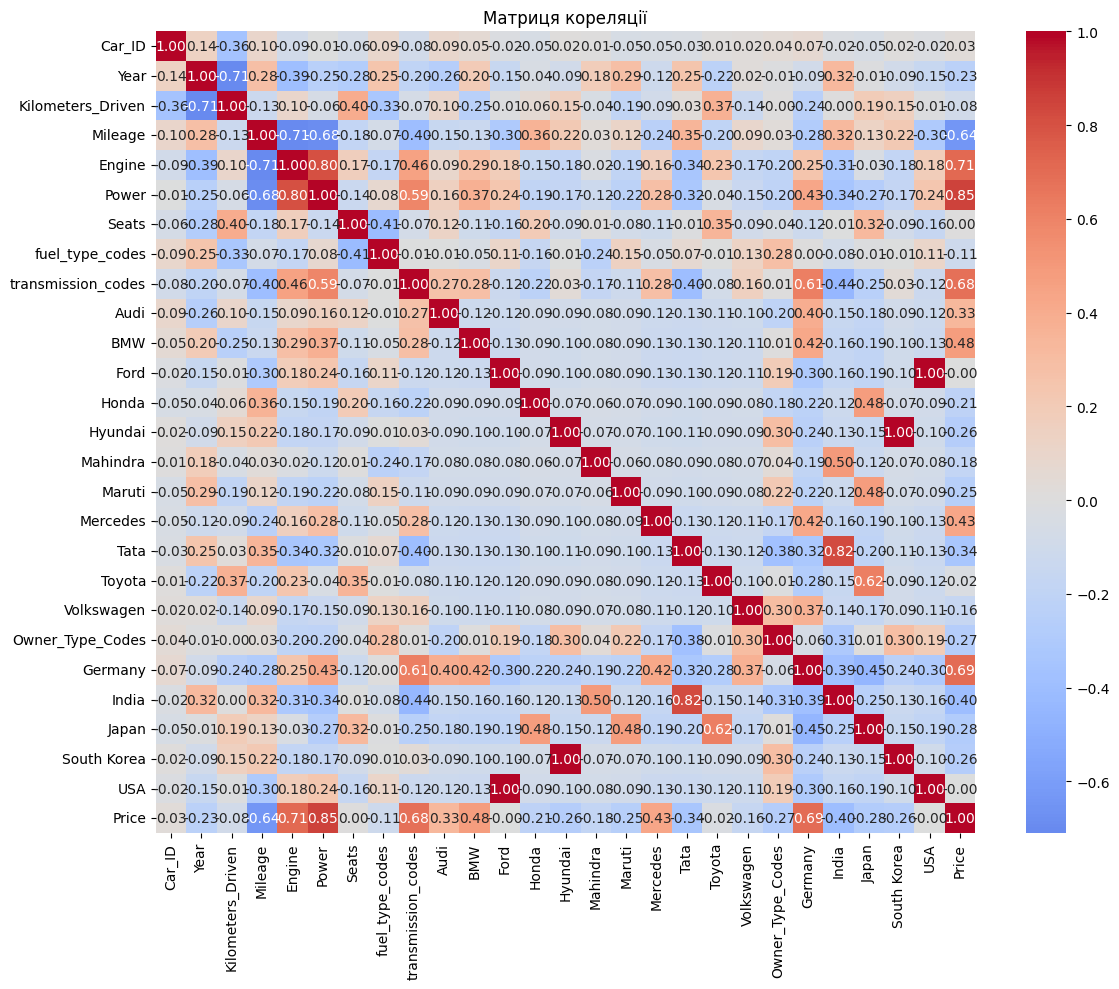

In [367]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Матриця кореляції')
plt.tight_layout()
plt.show()

Висновок: найбільше корелюють з таргетовою змінною (Price) колонки Power, Engine, Germany, transmission_codes, Mileage

#Завдання 6
**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [368]:
X_test = X_test.drop(['Model', 'Owner_Type'], axis=1)

In [369]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [392]:
def training_and_results(X_train, y_train, X_test, y_test):
  """Training and test of model, and vizualization of results"""
  #test dataset
  model = LinearRegression().fit(X_train, y_train)
  predictions_test = model.predict(X_test)
  test_rmse = np.sqrt(mean_squared_error(y_test, predictions_test))
  test_r2 = r2_score(y_test, predictions_test)
  test_mae = mean_absolute_error(y_test, predictions_test)
  print(f'Test Loss: {test_rmse:.2f}')
  print(f"R² score: {test_r2:.2f}")
  print(f"Mean Absolute Error: {test_mae:.2f}\n")

  print(f"mean_test: {(np.mean(y_test)):.2f}")
  print(f"std_test: {(np.std(y_test)):.2f}")
  print(f"min_test: {(np.min(y_test)):.2f}\n")

  #train dataset
  predictions_train = model.predict(X_train)
  train_rmse = np.sqrt(mean_squared_error(y_train, predictions_train))
  train_r2 = r2_score(y_train, predictions_train)
  train_mae = mean_absolute_error(y_train, predictions_train)

  print(f'Train Loss: {train_rmse:.2f}')
  print(f"R² score: {train_r2:.2f}")
  print(f"Mean Absolute Error: {train_mae:.2f}\n")

  print(f"mean_train: {(np.mean(y_train)):.2f}")
  print(f"std_train: {(np.std(y_train)):.2f}")
  print(f"min_train: {(np.min(y_train)):.2f}\n")

  #Візуальна оцінка роботи моделі на тестовому датасеті

  plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r', linewidth=2, label='Perfect predictions (y=x)')
  plt.scatter(y_test, predictions_test, color = 'b', s=8, alpha=0.8);
  plt.xlabel('Real Price');
  plt.ylabel('Predicted Price')
  plt.legend(['Estimate', 'Actual']);
  plt.title('Test Set: Predictions vs Actual', fontsize=14, fontweight='bold')
  plt.grid(True)
  plt.show()

  #Візуальна оцінка роботи моделі на тренувальному датасеті

  plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         'r', linewidth=2, label='Perfect predictions (y=x)')
  plt.scatter(y_train, predictions_train, color = 'b', s=8, alpha=0.8);
  plt.xlabel('Real Price');
  plt.ylabel('Predicted Price')
  plt.legend(['Estimate', 'Actual']);
  plt.title('Train Set: Predictions vs Actual', fontsize=14, fontweight='bold')
  plt.grid(True)
  plt.show()


  return model, predictions_test, predictions_train



Test Loss: 258181.56
R² score: 0.85
Mean Absolute Error: 208133.66

mean_test: 1150000.00
std_test: 672495.35
min_test: 450000.00

Train Loss: 210293.58
R² score: 0.96
Mean Absolute Error: 159756.38

mean_train: 1680000.00
std_train: 1033882.25
min_train: 450000.00



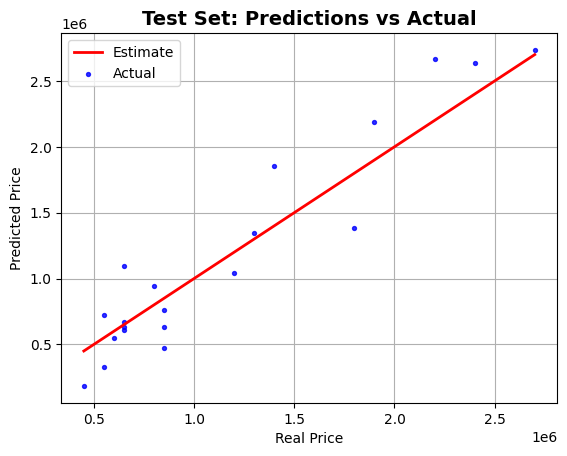

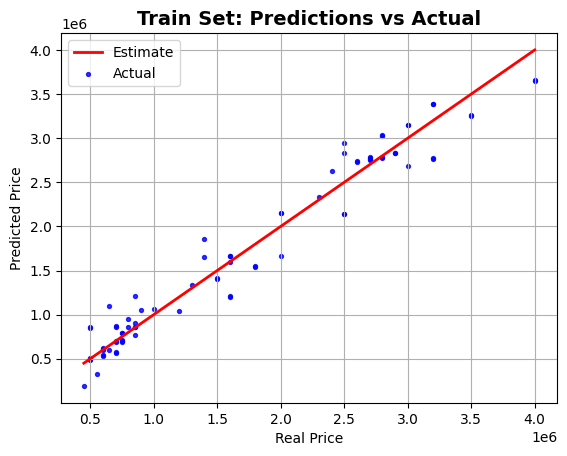

In [407]:
model_sklearn, predictions_sklearn_test, predictions_sklearn_train = training_and_results(X_train, y_train, X_test, y_test)

Висновок: З врахуванням метрик якості та візуального представлення моделі, можна зробити висновок, що вона доволі точно дає оцінки таргетовій змінній.

#Завдання 7
**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [408]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [425]:
scaler = StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [427]:
#Зберегти, як DataFrame
scaled_X_train = pd.DataFrame(
scaler.transform(X_train),
columns=X_train.columns,
index=X_train.index
)

scaled_X_test = pd.DataFrame(
scaler.transform(X_test),
columns=X_test.columns,
index=X_test.index
)

In [411]:
scaled_X_train

array([[ 1.09092769,  0.56881254, -0.69387081, ..., -0.53881591,
        -0.2847474 , -0.3560345 ],
       [ 0.10038127, -0.32344242, -0.03953291, ..., -0.53881591,
        -0.2847474 , -0.3560345 ],
       [-0.92554181, -0.32344242, -0.03953291, ..., -0.53881591,
        -0.2847474 , -0.3560345 ],
       ...,
       [-1.63307497, -0.32344242,  1.81442446, ..., -0.53881591,
        -0.2847474 , -0.3560345 ],
       [-0.89016515,  0.56881254, -0.69387081, ..., -0.53881591,
        -0.2847474 , -0.3560345 ],
       [ 0.80791442,  0.56881254, -0.69387081, ..., -0.53881591,
        -0.2847474 , -0.3560345 ]])

Test Loss: 258181.56
R² score: 0.85
Mean Absolute Error: 208133.66

mean_test: 1150000.00
std_test: 672495.35
min_test: 450000.00

Train Loss: 210293.58
R² score: 0.96
Mean Absolute Error: 159756.38

mean_train: 1680000.00
std_train: 1033882.25
min_train: 450000.00



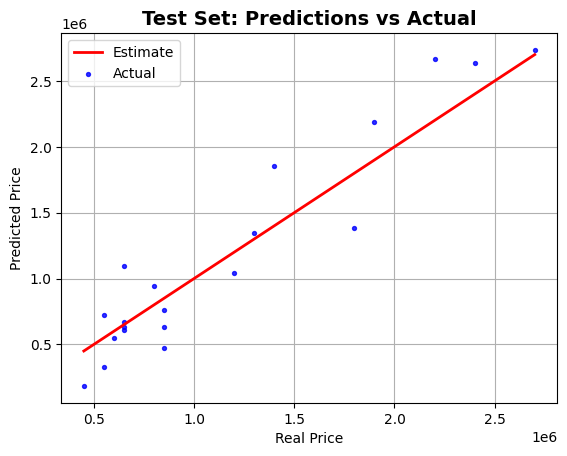

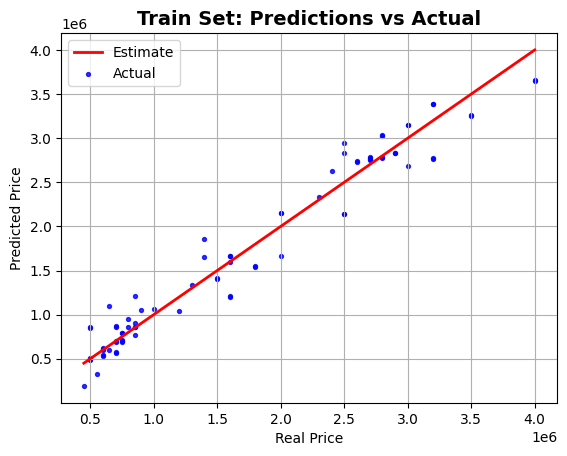

In [428]:
model_scaled, predictions_scaled_test, predictions_scaled_train = training_and_results(scaled_X_train, y_train, scaled_X_test, y_test)

In [431]:
features = list(scaled_X_train.columns) + ['intercept']
weight = np.append(model_scaled.coef_, model_scaled.intercept_)
weights_df = pd.DataFrame({
    'Feature': features,
    'weight': weight
  })

weights_df = weights_df.sort_values('weight', ascending=False)
print(weights_df)

               Feature        weight
26           intercept  1.680000e+06
5                Power  4.967692e+05
21             Germany  1.457845e+05
16            Mercedes  1.280744e+05
9                 Audi  1.277716e+05
10                 BMW  1.264329e+05
8   transmission_codes  1.166938e+05
18              Toyota  5.041882e+04
20    Owner_Type_Codes  4.234495e+04
0               Car_ID  5.608685e+03
6                Seats -2.148925e+03
17                Tata -2.493212e+03
1                 Year -8.765646e+03
4               Engine -2.137745e+04
23               Japan -3.284981e+04
12               Honda -3.482466e+04
11                Ford -5.330484e+04
25                 USA -5.330484e+04
22               India -5.901069e+04
24         South Korea -7.131783e+04
13             Hyundai -7.131783e+04
15              Maruti -8.433163e+04
2    Kilometers_Driven -9.439872e+04
14            Mahindra -9.909644e+04
3              Mileage -1.317155e+05
19          Volkswagen -1.662740e+05
7

Висновок:

Найвпливовішими на формування передбачення з точки зору коефіцієнтів є колонки Power, Germany, Mercedes, Audi, BMW, і схоже fuel_type_codes . В напрямку збільшення цільової змінної це Power  - тобто більш потужніші машини - дорожчі, що логічно, і також дорожчі німецькі машині. Стосовно змінних які впливають на зниження - це fuel_type_codes - мабуть менш ефектівні по витраті палива - якраз машини з потужним двигуном.

#Завдання 8.
** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [462]:
import statsmodels.api as sm

In [463]:
Y = y_train
X = scaled_X_train
X = sm.add_constant(X)
model = sm.OLS(Y,X)
results = model.fit()
results.params

,0
const,1.680000e+06
Car_ID,5.608685e+03
Year,-8.765646e+03
Kilometers_Driven,-9.439872e+04
Mileage,-1.317155e+05
Engine,-2.137745e+04
Power,4.967692e+05
Seats,-2.148925e+03
fuel_type_codes,-1.838480e+05
transmission_codes,1.166938e+05


In [464]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     68.35
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           2.01e-33
Time:                        22:40:04   Log-Likelihood:                -1094.0
No. Observations:                  80   AIC:                             2230.
Df Residuals:                      59   BIC:                             2280.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                1.68e+06   2.74

Висновок: стат значущими на рівні значущості 0.05:
Mileage
Power
fuel_type_codes
transmission_codes


In [465]:
def visual(y_test, y_train, predictions_test, predictions_train):
  #Візуальна оцінка роботи моделі на тестовому датасеті

  plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r', linewidth=2, label='Perfect predictions (y=x)')
  plt.scatter(y_test, predictions_test, color = 'b', s=8, alpha=0.8);
  plt.xlabel('Real Price');
  plt.ylabel('Predicted Price')
  plt.legend(['Estimate', 'Actual']);
  plt.title('Test Set: Predictions vs Actual', fontsize=14, fontweight='bold')
  plt.grid(True)
  plt.show()

  #Візуальна оцінка роботи моделі на тренувальному датасеті

  plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         'r', linewidth=2, label='Perfect predictions (y=x)')
  plt.scatter(y_train, predictions_train, color = 'b', s=8, alpha=0.8);
  plt.xlabel('Real Price');
  plt.ylabel('Predicted Price')
  plt.legend(['Estimate', 'Actual']);
  plt.title('Train Set: Predictions vs Actual', fontsize=14, fontweight='bold')
  plt.grid(True)
  plt.show()

In [466]:
#Predictions - додаємо константу перед predict!
predictions_train_statsmodels = results.predict(sm.add_constant(scaled_X_train))
predictions_test_statsmodels = results.predict(sm.add_constant(scaled_X_test))

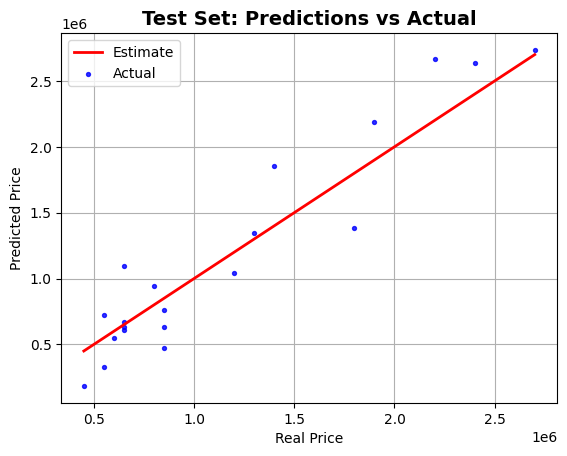

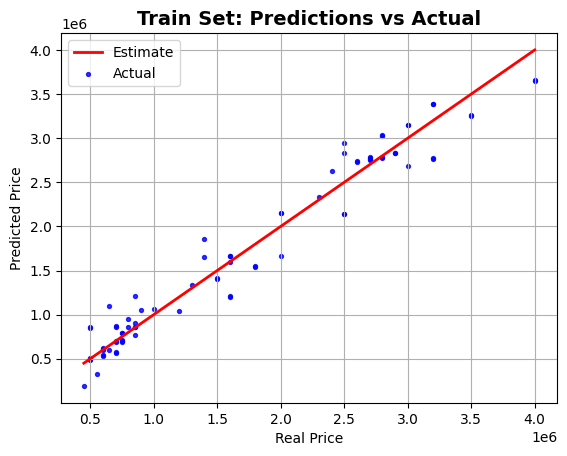

In [478]:
visual(y_test, y_train, predictions_test_statsmodels, predictions_train_statsmodels )

#Завдання 9
**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [484]:
Y= y_train
X_featured = scaled_X_train[['Mileage', 'Power', 'fuel_type_codes', 'transmission_codes']]
X_featured = sm.add_constant(X_featured)
model_featured = sm.OLS(Y,X_featured)
results_featured = model_featured.fit()
results_featured.params

,0
const,1.680000e+06
Mileage,-1.180635e+05
Power,6.487525e+05
fuel_type_codes,-1.707627e+05
transmission_codes,2.749238e+05


In [485]:
print(results_featured.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.795
Method:                 Least Squares   F-statistic:                     77.42
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           7.36e-26
Time:                        23:07:28   Log-Likelihood:                -1156.0
No. Observations:                  80   AIC:                             2322.
Df Residuals:                      75   BIC:                             2334.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                1.68e+06   5.27

Висновки: Показники моделі.  R2 і Adj. R-squared зменшились. Модель всеодно лишилась доволі хорошою, бо вона з початку мала високі показники. Проте, якби модель була з більш низьким R2, то це могло бути вирішальним фактором для неприйняття моделі в продакшн.

In [486]:

predictions_train_statsmodels_featured = results_featured.predict(sm.add_constant(X_featured))
predictions_test_statsmodels_featured = results_featured.predict(sm.add_constant(scaled_X_test[['Mileage', 'Power', 'fuel_type_codes', 'transmission_codes']]))

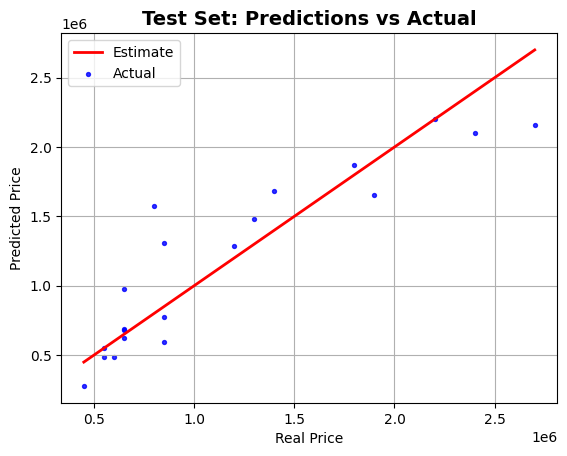

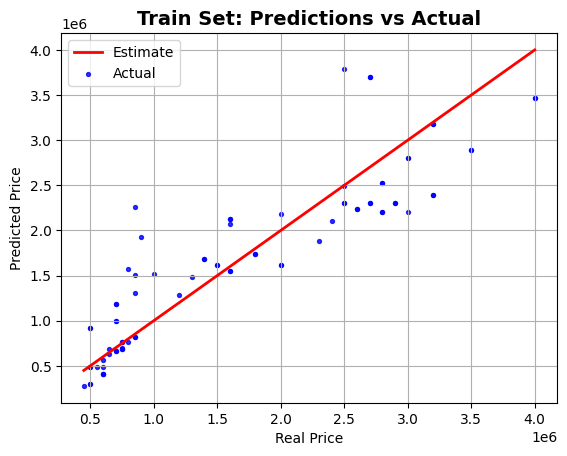

In [487]:
visual(y_test, y_train, predictions_test_statsmodels_featured, predictions_train_statsmodels_featured)

#Завдання 10
**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [488]:
Y= y_train
X_added_feature = scaled_X_train[['Mileage', 'Power', 'fuel_type_codes', 'transmission_codes','Kilometers_Driven']]
X_added_feature = sm.add_constant(X_added_feature)
model_added_feature = sm.OLS(Y,X_added_feature)
results_added_feature = model_added_feature.fit()
results_added_feature.params

,0
const,1.680000e+06
Mileage,-1.579650e+05
Power,6.223137e+05
fuel_type_codes,-2.120506e+05
transmission_codes,2.661810e+05
Kilometers_Driven,-1.217347e+05


In [490]:
print(results_added_feature.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.817
Model:                            OLS   Adj. R-squared:                  0.804
Method:                 Least Squares   F-statistic:                     65.86
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           7.50e-26
Time:                        23:07:53   Log-Likelihood:                -1153.6
No. Observations:                  80   AIC:                             2319.
Df Residuals:                      74   BIC:                             2333.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                1.68e+06   5.15

In [491]:
predictions_train_statsmodels_added_feature = results_added_feature.predict(sm.add_constant(X_added_feature))
predictions_test_statsmodels_added_feature = results_added_feature.predict(sm.add_constant(scaled_X_test[['Mileage', 'Power', 'fuel_type_codes', 'transmission_codes', 'Kilometers_Driven']]))

Висновки: Додавання ще одної ознаки - трохи покращило модель,проте накращим варіантом залишається навчання на повному тренувальному датасеті